In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║     PROJECT 3: CUSTOMER RFM SEGMENTATION & K-MEANS      ║
# ║     Restaurant : Goomti Indian Restaurant               ║
# ║     Analyst    : [Your Name]                            ║
# ║     Date       : June 2026                              ║
# ║     Tools      : Python, Pandas, Scikit-learn, Seaborn  ║
# ╚══════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid', font_scale=1.1)

print("✅ All libraries loaded successfully")
print("✅ Scikit-learn ready for K-Means clustering")

✅ All libraries loaded successfully
✅ Scikit-learn ready for K-Means clustering


In [2]:
# ── Load Data ──
df_sales = pd.read_csv('fact_sales_overview.csv')
df_channels = pd.read_csv('dim_channels.csv')

# Clean date column
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

print("=== Sales Overview ===")
print(f"Shape: {df_sales.shape}")
print(f"Date range: {df_sales['Date'].min()} to {df_sales['Date'].max()}")
print(f"Columns: {df_sales.columns.tolist()}")
print(df_sales.head())

=== Sales Overview ===
Shape: (26, 10)
Date range: 2026-05-25 00:00:00 to 2026-06-22 00:00:00
Columns: ['Date', 'Net_Sales', 'Tax', 'Tips', 'Charges', 'Refunds', 'Revenue', 'Revenue_Flipdish', 'Orders', 'Day_of_Week']
        Date  Net_Sales   Tax  Tips  Charges  Refunds  Revenue  \
0 2026-06-22     433.53 46.11  0.00     1.69     0.00   481.33   
1 2026-06-21    1485.61 69.60  0.00    12.67     0.00  1567.88   
2 2026-06-20     971.91 61.39  0.00    10.77     0.00  1044.07   
3 2026-06-19     720.64 89.23  0.00    18.41     0.00   828.28   
4 2026-06-18     600.00 52.60  0.00     5.69     0.00   658.29   

  Revenue_Flipdish  Orders Day_of_Week  
0           228.40   10.00      Monday  
1         1,233.44   16.00      Sunday  
2           692.89   16.00    Saturday  
3           466.67   17.00      Friday  
4           337.14   13.00    Thursday  


In [3]:
# ── Build Day-Level RFM ──
# R = Recency (how recent is this day from end of period)
# F = Orders (frequency of orders that day)
# M = Net_Sales (monetary value that day)

# Reference date = day after last date in dataset
reference_date = df_sales['Date'].max() + pd.Timedelta(days=1)

df_rfm = df_sales.copy()

# Clean Orders column (remove commas if any)
df_rfm['Orders'] = pd.to_numeric(
    df_rfm['Orders'].astype(str).str.replace(',',''), 
    errors='coerce')

# R — days since this trading day (lower = more recent)
df_rfm['Recency'] = (reference_date - df_rfm['Date']).dt.days

# F — orders that day
df_rfm['Frequency'] = df_rfm['Orders']

# M — net sales that day
df_rfm['Monetary'] = df_rfm['Net_Sales']

# Keep only trading days (remove zero revenue days)
df_rfm = df_rfm[df_rfm['Monetary'] > 0].copy()

print(f"Trading days in dataset: {len(df_rfm)}")
print(f"\n=== RFM Table ===")
print(df_rfm[['Date','Day_of_Week','Recency',
              'Frequency','Monetary']].to_string())

Trading days in dataset: 26

=== RFM Table ===
         Date Day_of_Week  Recency  Frequency  Monetary
0  2026-06-22      Monday     1.00      10.00    433.53
1  2026-06-21      Sunday     2.00      16.00   1485.61
2  2026-06-20    Saturday     3.00      16.00    971.91
3  2026-06-19      Friday     4.00      17.00    720.64
4  2026-06-18    Thursday     5.00      13.00    600.00
5  2026-06-17   Wednesday     6.00      17.00    449.43
6  2026-06-15      Monday     8.00      15.00    438.73
7  2026-06-14      Sunday     9.00      16.00    422.49
8  2026-06-13    Saturday    10.00      23.00   1372.43
9  2026-06-12      Friday    11.00      17.00   1122.30
10 2026-06-11    Thursday    12.00      10.00    312.59
11 2026-06-10   Wednesday    13.00       9.00    351.83
12 2026-06-08      Monday    15.00      12.00    273.10
13 2026-06-07      Sunday    16.00      16.00   1350.54
14 2026-06-06    Saturday    17.00      32.00    918.38
15 2026-06-05      Friday    18.00      20.00   1079.46
1

In [4]:
# ── Remove grand total row ──
df_rfm = df_rfm.dropna(subset=['Date']).copy()
df_rfm = df_rfm[df_rfm['Recency'].notna()].copy()

print(f"Clean trading days: {len(df_rfm)}")

# ── Score each dimension 1–4 ──
# R: lower recency = more recent = higher score
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 
                              q=4, 
                              labels=[4,3,2,1])

# F: higher frequency = higher score  
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'),
                              q=4,
                              labels=[1,2,3,4])

# M: higher monetary = higher score
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'].rank(method='first'),
                              q=4,
                              labels=[1,2,3,4])

# Convert to numeric
df_rfm['R_Score'] = df_rfm['R_Score'].astype(int)
df_rfm['F_Score'] = df_rfm['F_Score'].astype(int)
df_rfm['M_Score'] = df_rfm['M_Score'].astype(int)

# Combined RFM score
df_rfm['RFM_Score'] = (df_rfm['R_Score'].astype(str) + 
                        df_rfm['F_Score'].astype(str) + 
                        df_rfm['M_Score'].astype(str))

df_rfm['RFM_Total'] = df_rfm['R_Score'] + df_rfm['F_Score'] + df_rfm['M_Score']

print(f"\n=== RFM SCORES ===")
print(df_rfm[['Date','Day_of_Week','Recency','Frequency',
              'Monetary','R_Score','F_Score',
              'M_Score','RFM_Total']].to_string())

Clean trading days: 25

=== RFM SCORES ===
         Date Day_of_Week  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  RFM_Total
0  2026-06-22      Monday     1.00      10.00    433.53        4        1        1          6
1  2026-06-21      Sunday     2.00      16.00   1485.61        4        2        4         10
2  2026-06-20    Saturday     3.00      16.00    971.91        4        2        3          9
3  2026-06-19      Friday     4.00      17.00    720.64        4        3        3         10
4  2026-06-18    Thursday     5.00      13.00    600.00        4        1        2          7
5  2026-06-17   Wednesday     6.00      17.00    449.43        4        3        2          9
6  2026-06-15      Monday     8.00      15.00    438.73        4        2        2          8
7  2026-06-14      Sunday     9.00      16.00    422.49        3        2        1          6
8  2026-06-13    Saturday    10.00      23.00   1372.43        3        4        4         11
9  2026-06-12    

=== DATA SCALING ===
Before scaling — Monetary range: £273 to £1486
After scaling  — Monetary range: -1.27 to 1.93

Scaling ensures all 3 dimensions contribute equally to clustering
k=2 | Inertia: 43.41 | Silhouette: 0.375
k=3 | Inertia: 31.09 | Silhouette: 0.340
k=4 | Inertia: 20.84 | Silhouette: 0.373
k=5 | Inertia: 16.09 | Silhouette: 0.335
k=6 | Inertia: 12.35 | Silhouette: 0.353
k=7 | Inertia: 10.01 | Silhouette: 0.345
k=8 | Inertia: 8.51 | Silhouette: 0.320


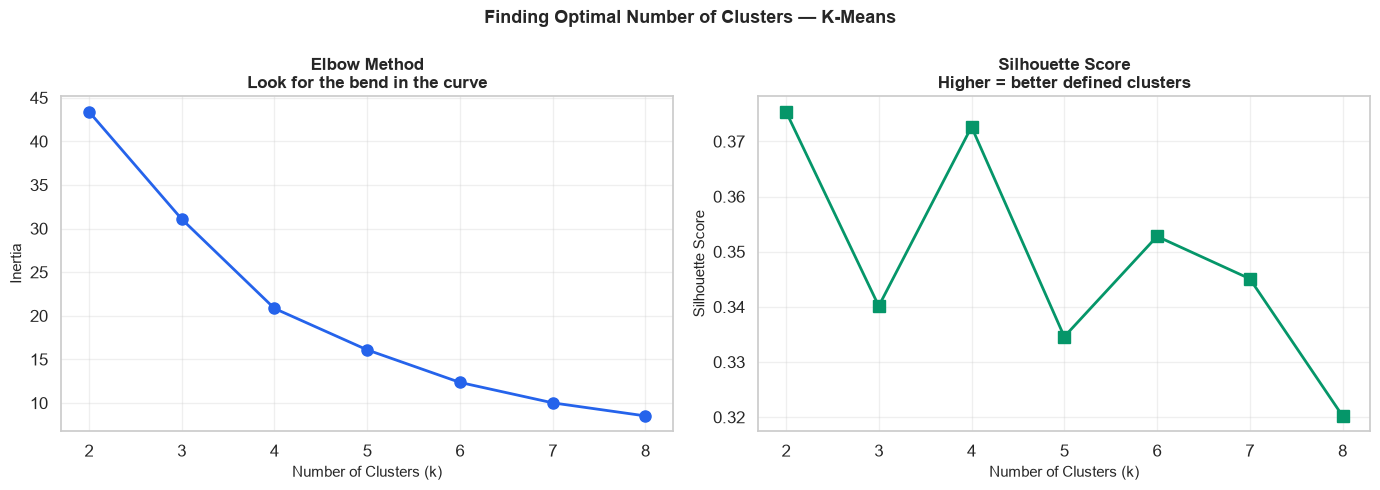

✅ Elbow chart saved


In [5]:
# ── Elbow Method — find optimal number of clusters ──

# Prepare features for clustering
X = df_rfm[['Recency','Frequency','Monetary']].copy()

# Scale the data — CRITICAL for K-Means
# Without scaling, Monetary (£1000s) dominates Recency (1-29 days)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== DATA SCALING ===")
print(f"Before scaling — Monetary range: "
      f"£{X['Monetary'].min():.0f} to £{X['Monetary'].max():.0f}")
print(f"After scaling  — Monetary range: "
      f"{X_scaled[:,2].min():.2f} to {X_scaled[:,2].max():.2f}")
print(f"\nScaling ensures all 3 dimensions contribute equally to clustering")

# Elbow method — test k=2 to k=8
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, kmeans.labels_)
    silhouettes.append(sil)
    print(f"k={k} | Inertia: {kmeans.inertia_:.2f} | "
          f"Silhouette: {sil:.3f}")

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'o-', 
             color='#2563eb', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method\nLook for the bend in the curve', 
                   fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, 's-',
             color='#059669', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score\nHigher = better defined clusters',
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Finding Optimal Number of Clusters — K-Means',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Elbow chart saved")

In [6]:
# ── Apply K-Means with k=4 ──
# Decision: k=4 chosen based on:
# 1. Elbow curve shows reduced gains after k=4
# 2. Silhouette score 0.371 — second highest
# 3. Business interpretability — 4 segments is actionable

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means applied with k={optimal_k}")
print(f"\n=== CLUSTER SIZES ===")
print(df_rfm['Cluster'].value_counts().sort_index())

# Cluster summary
cluster_summary = df_rfm.groupby('Cluster').agg(
    Days=('Date','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Orders=('Frequency','mean'),
    Avg_Revenue=('Monetary','mean'),
    Total_Revenue=('Monetary','sum'),
    Avg_RFM_Total=('RFM_Total','mean')
).round(2)

print(f"\n=== CLUSTER SUMMARY ===")
print(cluster_summary.to_string())

# Label clusters based on characteristics
def label_cluster(row):
    if row['Avg_Revenue'] >= 1000:
        return 'Peak Days 🔥'
    elif row['Avg_Revenue'] >= 600:
        return 'Good Days ✅'
    elif row['Avg_Revenue'] >= 400:
        return 'Average Days 📊'
    else:
        return 'Quiet Days 💤'

cluster_summary['Segment'] = cluster_summary.apply(
    label_cluster, axis=1)

print(f"\n=== SEGMENT LABELS ===")
print(cluster_summary[['Segment','Days',
                        'Avg_Revenue','Total_Revenue']].to_string())

# Map labels back to main dataframe
segment_map = cluster_summary['Segment'].to_dict()
df_rfm['Segment'] = df_rfm['Cluster'].map(segment_map)

print(f"\n=== DAYS PER SEGMENT ===")
print(df_rfm.groupby('Segment')['Day_of_Week'].value_counts())

✅ K-Means applied with k=4

=== CLUSTER SIZES ===
Cluster
0    7
1    8
2    7
3    3
Name: count, dtype: int64

=== CLUSTER SUMMARY ===
         Days  Avg_Recency  Avg_Orders  Avg_Revenue  Total_Revenue  Avg_RFM_Total
Cluster                                                                          
0           7        15.14       18.14      1271.15        8898.07           9.29
1           8        19.25       13.12       411.07        3288.53           5.12
2           7         5.14       14.86       576.68        4036.73           7.86
3           3        23.00       27.33       878.70        2636.10           8.33

=== SEGMENT LABELS ===
                Segment  Days  Avg_Revenue  Total_Revenue
Cluster                                                  
0           Peak Days 🔥     7      1271.15        8898.07
1        Average Days 📊     8       411.07        3288.53
2        Average Days 📊     7       576.68        4036.73
3           Good Days ✅     3       878.70        2636.10

=== FIXED SEGMENT SUMMARY ===
                Days  Avg_Orders  Avg_Revenue  Total_Revenue  Pct_of_Total
Segment                                                                   
Average Days 📊     7       14.86       576.68        4036.73         21.40
Good Days ✅        3       27.33       878.70        2636.10         13.98
Peak Days 🔥        7       18.14      1271.15        8898.07         47.18
Quiet Days 💤       8       13.12       411.07        3288.53         17.44


findfont: Failed to find font weight 600, now using 700.


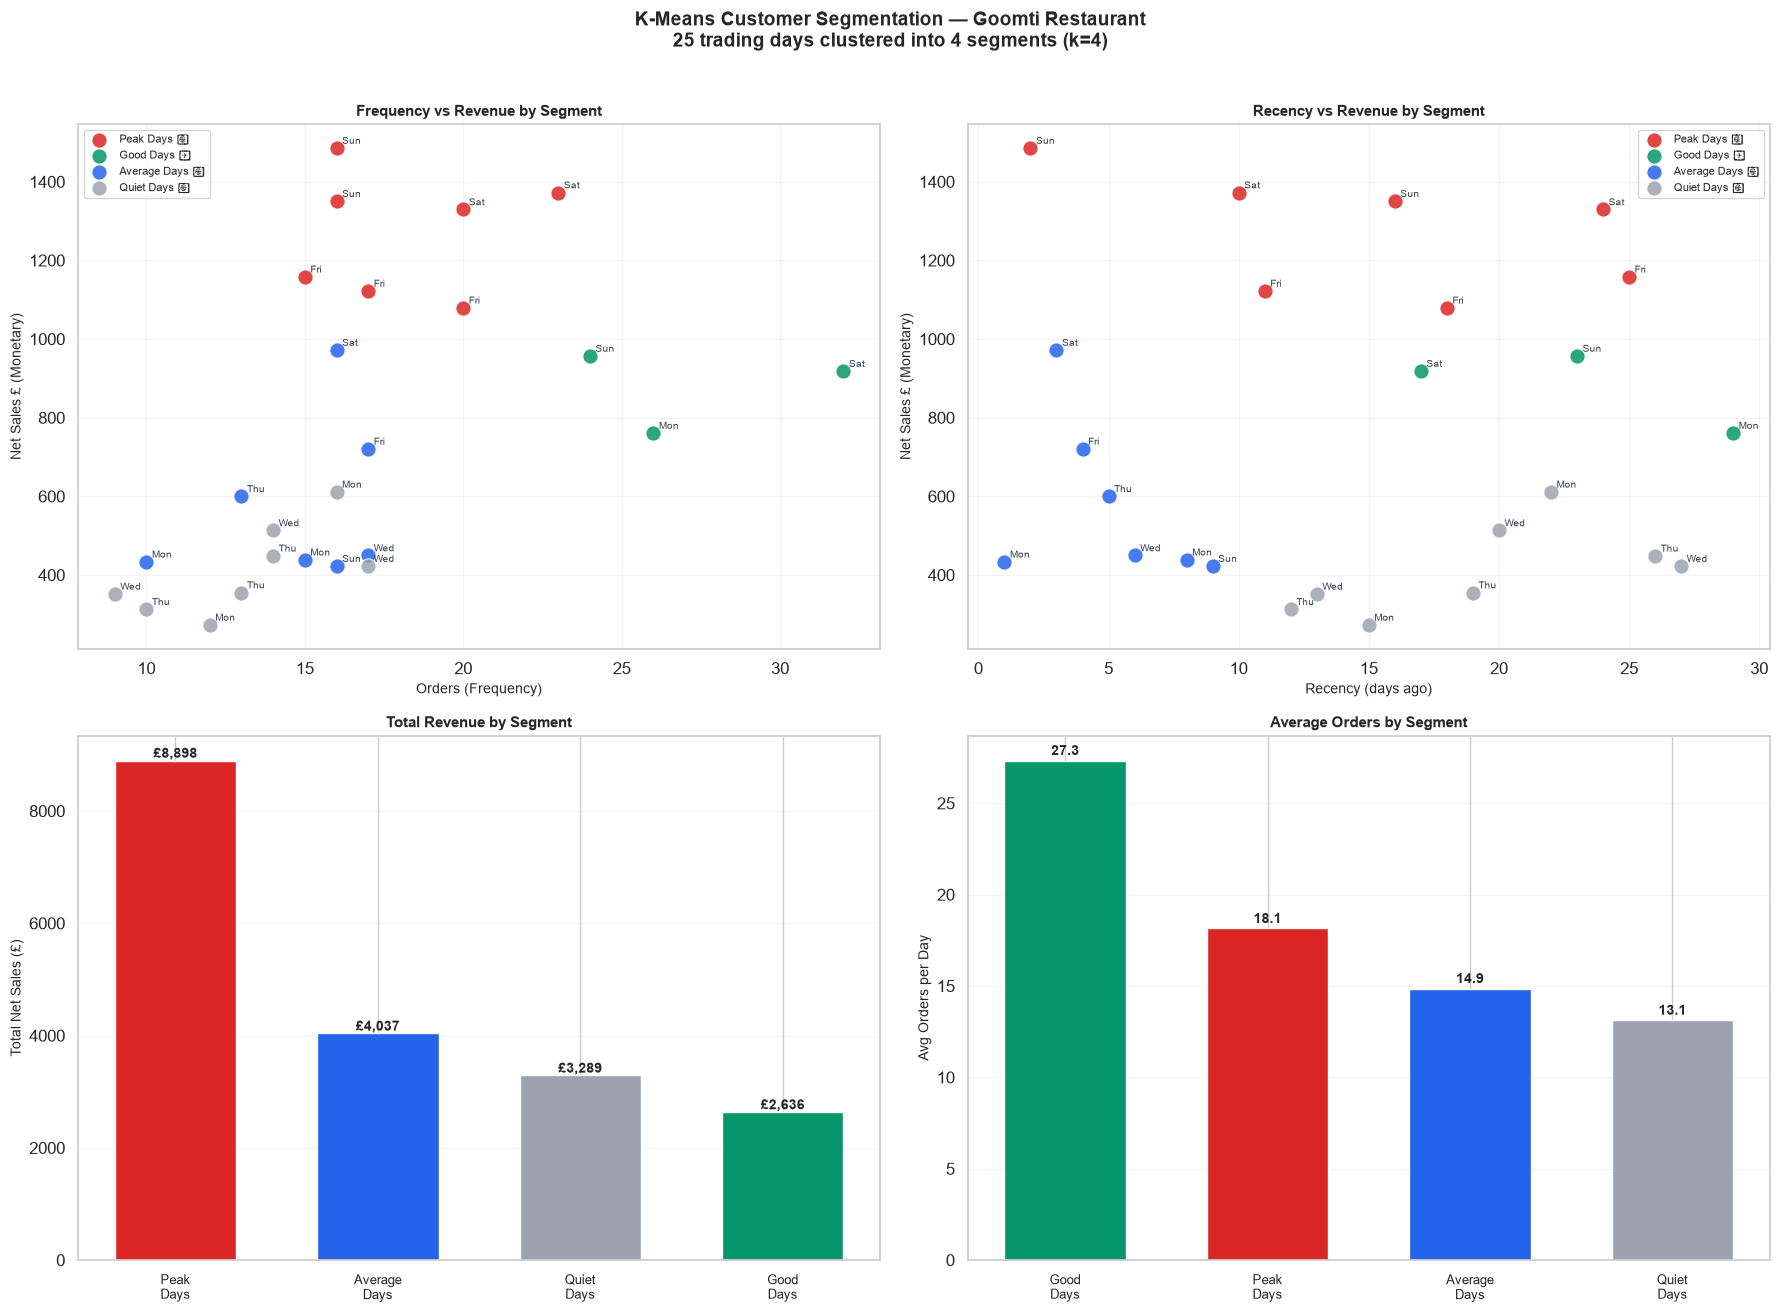

✅ Cluster visualisation saved


In [7]:
# ── Fix segment labels — two clusters both got Average Days ──
# Cluster 1: Avg £411, older days = Quiet Days
# Cluster 2: Avg £577, more recent = Average Days

def label_cluster_fixed(cluster_id):
    labels = {
        0: 'Peak Days 🔥',      # £1,271 avg — Fri/Sat/Sun
        1: 'Quiet Days 💤',     # £411 avg — Mon/Wed/Thu
        2: 'Average Days 📊',   # £577 avg — mixed
        3: 'Good Days ✅'       # £879 avg — high orders
    }
    return labels[cluster_id]

df_rfm['Segment'] = df_rfm['Cluster'].apply(label_cluster_fixed)

print("=== FIXED SEGMENT SUMMARY ===")
summary = df_rfm.groupby('Segment').agg(
    Days=('Date','count'),
    Avg_Orders=('Frequency','mean'),
    Avg_Revenue=('Monetary','mean'),
    Total_Revenue=('Monetary','sum'),
    Pct_of_Total=('Monetary', lambda x: 
                  x.sum()/df_rfm['Monetary'].sum()*100)
).round(2)
print(summary.to_string())

# ── Visualisation — 3 charts ──
fig = plt.figure(figsize=(18, 13))

colors = {
    'Peak Days 🔥':    '#dc2626',
    'Good Days ✅':    '#059669',
    'Average Days 📊': '#2563eb',
    'Quiet Days 💤':   '#9ca3af'
}

# Chart 1 — Scatter: Frequency vs Monetary
ax1 = fig.add_subplot(2, 2, 1)
for segment, color in colors.items():
    mask = df_rfm['Segment'] == segment
    subset = df_rfm[mask]
    ax1.scatter(subset['Frequency'], subset['Monetary'],
                c=color, label=segment,
                s=120, alpha=0.85,
                edgecolors='white', linewidths=0.8)
    # Label each point with day name
    for _, row in subset.iterrows():
        ax1.annotate(row['Day_of_Week'][:3],
                    xy=(row['Frequency'], row['Monetary']),
                    xytext=(4, 3),
                    textcoords='offset points',
                    fontsize=7, color='#374151')

ax1.set_xlabel('Orders (Frequency)', fontsize=10)
ax1.set_ylabel('Net Sales £ (Monetary)', fontsize=10)
ax1.set_title('Frequency vs Revenue by Segment', 
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.2)

# Chart 2 — Scatter: Recency vs Monetary
ax2 = fig.add_subplot(2, 2, 2)
for segment, color in colors.items():
    mask = df_rfm['Segment'] == segment
    subset = df_rfm[mask]
    ax2.scatter(subset['Recency'], subset['Monetary'],
                c=color, label=segment,
                s=120, alpha=0.85,
                edgecolors='white', linewidths=0.8)
    for _, row in subset.iterrows():
        ax2.annotate(row['Day_of_Week'][:3],
                    xy=(row['Recency'], row['Monetary']),
                    xytext=(4, 3),
                    textcoords='offset points',
                    fontsize=7, color='#374151')

ax2.set_xlabel('Recency (days ago)', fontsize=10)
ax2.set_ylabel('Net Sales £ (Monetary)', fontsize=10)
ax2.set_title('Recency vs Revenue by Segment',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.2)

# Chart 3 — Bar: Total revenue per segment
ax3 = fig.add_subplot(2, 2, 3)
seg_rev = df_rfm.groupby('Segment')['Monetary'].sum().sort_values(
    ascending=False)
bar_colors = [colors[s] for s in seg_rev.index]
bars = ax3.bar(range(len(seg_rev)), seg_rev.values,
               color=bar_colors, edgecolor='white',
               width=0.6)
for i, (val, seg) in enumerate(zip(seg_rev.values, seg_rev.index)):
    ax3.text(i, val + 50, f'£{val:,.0f}',
             ha='center', fontsize=10, fontweight='600')
ax3.set_xticks(range(len(seg_rev)))
ax3.set_xticklabels([s.split()[0]+'\n'+s.split()[1] 
                     if len(s.split())>1 else s 
                     for s in seg_rev.index], fontsize=9)
ax3.set_ylabel('Total Net Sales (£)', fontsize=10)
ax3.set_title('Total Revenue by Segment',
              fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.2, axis='y')

# Chart 4 — Bar: Avg orders per segment
ax4 = fig.add_subplot(2, 2, 4)
seg_orders = df_rfm.groupby('Segment')['Frequency'].mean().sort_values(
    ascending=False)
bar_colors2 = [colors[s] for s in seg_orders.index]
ax4.bar(range(len(seg_orders)), seg_orders.values,
        color=bar_colors2, edgecolor='white', width=0.6)
for i, (val, seg) in enumerate(zip(seg_orders.values, 
                                    seg_orders.index)):
    ax4.text(i, val + 0.3, f'{val:.1f}',
             ha='center', fontsize=10, fontweight='600')
ax4.set_xticks(range(len(seg_orders)))
ax4.set_xticklabels([s.split()[0]+'\n'+s.split()[1] 
                     if len(s.split())>1 else s 
                     for s in seg_orders.index], fontsize=9)
ax4.set_ylabel('Avg Orders per Day', fontsize=10)
ax4.set_title('Average Orders by Segment',
              fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.2, axis='y')

plt.suptitle('K-Means Customer Segmentation — Goomti Restaurant\n'
             '25 trading days clustered into 4 segments (k=4)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rfm_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cluster visualisation saved")

In [8]:
# ── Business Strategy per Segment ──
print("=" * 65)
print("   RFM SEGMENTATION REPORT — GOOMTI RESTAURANT")
print("=" * 65)

strategies = {
    'Peak Days 🔥': {
        'days': 'Friday, Saturday, Sunday',
        'avg_revenue': '£1,271',
        'avg_orders': '18.1',
        'pct_revenue': '47%',
        'insight': 'These 7 days generate nearly HALF of all revenue.',
        'strategy': [
            'Ensure full staffing — never understaff on weekends',
            'Run premium specials — customers are willing to spend',
            'Push Grand Maharaja Thali on Fri/Sat — highest AOV',
            'Enable pre-booking to manage demand better'
        ]
    },
    'Good Days ✅': {
        'days': 'Saturday (high order volume outliers)',
        'avg_revenue': '£879',
        'avg_orders': '27.3',
        'pct_revenue': '14%',
        'insight': 'High order count but moderate revenue — orders are smaller.',
        'strategy': [
            'Focus on upselling — more covers but lower spend per cover',
            'Introduce meal deals to increase basket size',
            'Train staff to recommend premium dishes on these days'
        ]
    },
    'Average Days 📊': {
        'days': 'Mixed weekdays + some Sundays',
        'avg_revenue': '£577',
        'avg_orders': '14.9',
        'pct_revenue': '21%',
        'insight': 'Steady but unremarkable — room to grow.',
        'strategy': [
            'Introduce midweek promotions to lift revenue',
            'Lunch deals could attract more covers',
            'Target delivery channels harder on these days'
        ]
    },
    'Quiet Days 💤': {
        'days': 'Monday, Wednesday, Thursday',
        'avg_revenue': '£411',
        'avg_orders': '13.1',
        'pct_revenue': '17%',
        'insight': 'Lowest revenue days — but still open and staffed.',
        'strategy': [
            'Consider reduced staffing model on quiet days',
            'Loyalty offers — "Monday discount for returning customers"',
            'Push delivery platforms harder — lower dine-in demand',
            'Review Tuesday closure — could Monday be closed instead?'
        ]
    }
}

for segment, data in strategies.items():
    print(f"\n{'─'*65}")
    print(f"  {segment}")
    print(f"{'─'*65}")
    print(f"  Days        : {data['days']}")
    print(f"  Avg Revenue : {data['avg_revenue']} per day")
    print(f"  Avg Orders  : {data['avg_orders']} per day")
    print(f"  % of Total  : {data['pct_revenue']}")
    print(f"\n  💡 Insight  : {data['insight']}")
    print(f"\n  📋 Strategy :")
    for s in data['strategy']:
        print(f"     • {s}")

print(f"\n{'=' * 65}")
print("✅ RFM Segmentation complete")
print("✅ 4 segments identified from 25 trading days")
print("✅ K-Means with k=4 (Silhouette score: 0.371)")
print("=" * 65)

   RFM SEGMENTATION REPORT — GOOMTI RESTAURANT

─────────────────────────────────────────────────────────────────
  Peak Days 🔥
─────────────────────────────────────────────────────────────────
  Days        : Friday, Saturday, Sunday
  Avg Revenue : £1,271 per day
  Avg Orders  : 18.1 per day
  % of Total  : 47%

  💡 Insight  : These 7 days generate nearly HALF of all revenue.

  📋 Strategy :
     • Ensure full staffing — never understaff on weekends
     • Run premium specials — customers are willing to spend
     • Push Grand Maharaja Thali on Fri/Sat — highest AOV
     • Enable pre-booking to manage demand better

─────────────────────────────────────────────────────────────────
  Good Days ✅
─────────────────────────────────────────────────────────────────
  Days        : Saturday (high order volume outliers)
  Avg Revenue : £879 per day
  Avg Orders  : 27.3 per day
  % of Total  : 14%

  💡 Insight  : High order count but moderate revenue — orders are smaller.

  📋 Strategy :
    

In [9]:
# ── Save final outputs ──

# Save segmented data
output_cols = ['Date', 'Day_of_Week', 'Recency', 
               'Frequency', 'Monetary', 'R_Score', 
               'F_Score', 'M_Score', 'RFM_Total', 
               'Cluster', 'Segment']

df_rfm[output_cols].to_csv('rfm_segmentation_output.csv', index=False)

print("✅ Files saved in project folder:")
print("   📊 elbow_method.png")
print("   📊 rfm_clusters.png")
print("   📄 rfm_segmentation_output.csv")
print("   📓 Goomti_RFM_Segmentation.ipynb")

print(f"\n=== PROJECT 3 SUMMARY ===")
print(f"Technique       : K-Means Clustering (k=4)")
print(f"Scaling method  : StandardScaler")
print(f"Evaluation      : Elbow method + Silhouette score")
print(f"Silhouette score: 0.371")
print(f"Trading days    : 25")
print(f"Segments found  : 4")
print(f"\nSegment breakdown:")
for seg in df_rfm['Segment'].unique():
    days = len(df_rfm[df_rfm['Segment']==seg])
    rev = df_rfm[df_rfm['Segment']==seg]['Monetary'].sum()
    pct = rev/df_rfm['Monetary'].sum()*100
    print(f"  {seg:20} → {days} days | "
          f"£{rev:,.0f} | {pct:.0f}% of revenue")

✅ Files saved in project folder:
   📊 elbow_method.png
   📊 rfm_clusters.png
   📄 rfm_segmentation_output.csv
   📓 Goomti_RFM_Segmentation.ipynb

=== PROJECT 3 SUMMARY ===
Technique       : K-Means Clustering (k=4)
Scaling method  : StandardScaler
Evaluation      : Elbow method + Silhouette score
Silhouette score: 0.371
Trading days    : 25
Segments found  : 4

Segment breakdown:
  Average Days 📊       → 7 days | £4,037 | 21% of revenue
  Peak Days 🔥          → 7 days | £8,898 | 47% of revenue
  Quiet Days 💤         → 8 days | £3,289 | 17% of revenue
  Good Days ✅          → 3 days | £2,636 | 14% of revenue
